# Data Assessment & Analytics for Water Rights
Notes:
- change os directory location
- be aware of the number of provdied native source data files
- beware of of what data is available

In [1]:
# Needed Libraries / Modules

# ---- working with data ----
import os  # native operating system interaction
import numpy as np  # mathematical array manipulation
import pandas as pd  # data structure and data analysis
import geopandas as gpd  # geo-data structure and data analysis

# ---- visualization ----
import geoplot as gplt  # for plotting maps and geo-data
import geoplot.crs as gcrs  #used to pull in webdata related to maps and geo-data
import missingno as msno # creates a matrix chart to show missing values
import plotly.express as px
import plotly.graph_objects as go  # for subplot creation
from plotly.subplots import make_subplots  # for subplot creation
import matplotlib.pyplot as mplt  # use with gplt to save fig to pdf

# ---- cleanup ----
import re # string regular expression manipulation
from datetime import datetime # date and time manipulation
pd.set_option('display.max_columns', 999)  # How to display all columns of a Pandas DataFrame in Jupyter Notebook
pd.set_option('display.float_format', lambda x: '%.5f' % x) # suppress scientific notation in Pandas

In [2]:
# ---- working directory ----
workingDirString = os.getcwd() # set working directory folder string here
os.chdir(workingDirString)
print(f'The working Directory is:', workingDirString)

The working Directory is: C:\Users\rjame\Documents\WSWC Documents\MappingStatesDataToWaDE2.0\Kansas\WaterAllocation


In [3]:
# ---- where to find input files ----
InputFolderString = "G:/Shared drives/WaDE Data/WaDE Data Folder/Kansas/WaterAllocation"  # set this to where input files are located

In [4]:
# Native Input Data
#################################################################
# ---- This needs to be custom per state ----

# Data Set 1: qty_20260205502
dfin1 = pd.read_csv(InputFolderString + '/RawinputData/qty_20260205502.zip')

# Data Set 2: wimas_20260205600
dfin2 = pd.read_csv(InputFolderString + '/RawinputData/wimas_20260205600.zip')

C:\Users\rjame\AppData\Local\Temp\ipykernel_4916\1546095491.py:6: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  dfin1 = pd.read_csv(InputFolderString + '/RawinputData/qty_20260205502.zip')


In [5]:
# WaDE Processed Input Data
#################################################################

dfm = pd.read_csv(InputFolderString + "/ProcessedInputData/methods.csv", encoding = "ISO-8859-1").replace(np.nan, "")

dfv = pd.read_csv(InputFolderString + "/ProcessedInputData/variables.csv", encoding = "ISO-8859-1").replace(np.nan, "")

dfo = pd.read_csv(InputFolderString + "/ProcessedInputData/organizations.csv", encoding = "ISO-8859-1").replace(np.nan, "")

dfws = pd.read_csv(InputFolderString + "/ProcessedInputData/watersources.csv").replace(np.nan, "")
dfwspurge = pd.read_csv(InputFolderString + "/ProcessedInputData/watersources_missing.csv").replace(np.nan, "")

dfs = pd.read_csv(InputFolderString + "/ProcessedInputData/sites.csv").replace(np.nan, "")
dfspurge = pd.read_csv(InputFolderString + "/ProcessedInputData/sites_missing.csv").replace(np.nan, "")

dfaa = pd.read_csv(InputFolderString + "/ProcessedInputData/waterallocations.csv").replace(np.nan, "")
dfaapurge = pd.read_csv(InputFolderString + "/ProcessedInputData/waterallocations_missing.csv").replace(np.nan, "")

# Water Source Info (watersources.csv)

In [6]:
print(len(dfws))
dfws.head(1)

121


,WaterSourceUUID,Geometry,GNISFeatureNameCV,WaterQualityIndicatorCV,WaterSourceName,WaterSourceNativeID,WaterSourceTypeCV
0,KSwr_WwadeId1,,,Fresh,Sappa Creek,wadeId1,Groundwater


<Axes: >

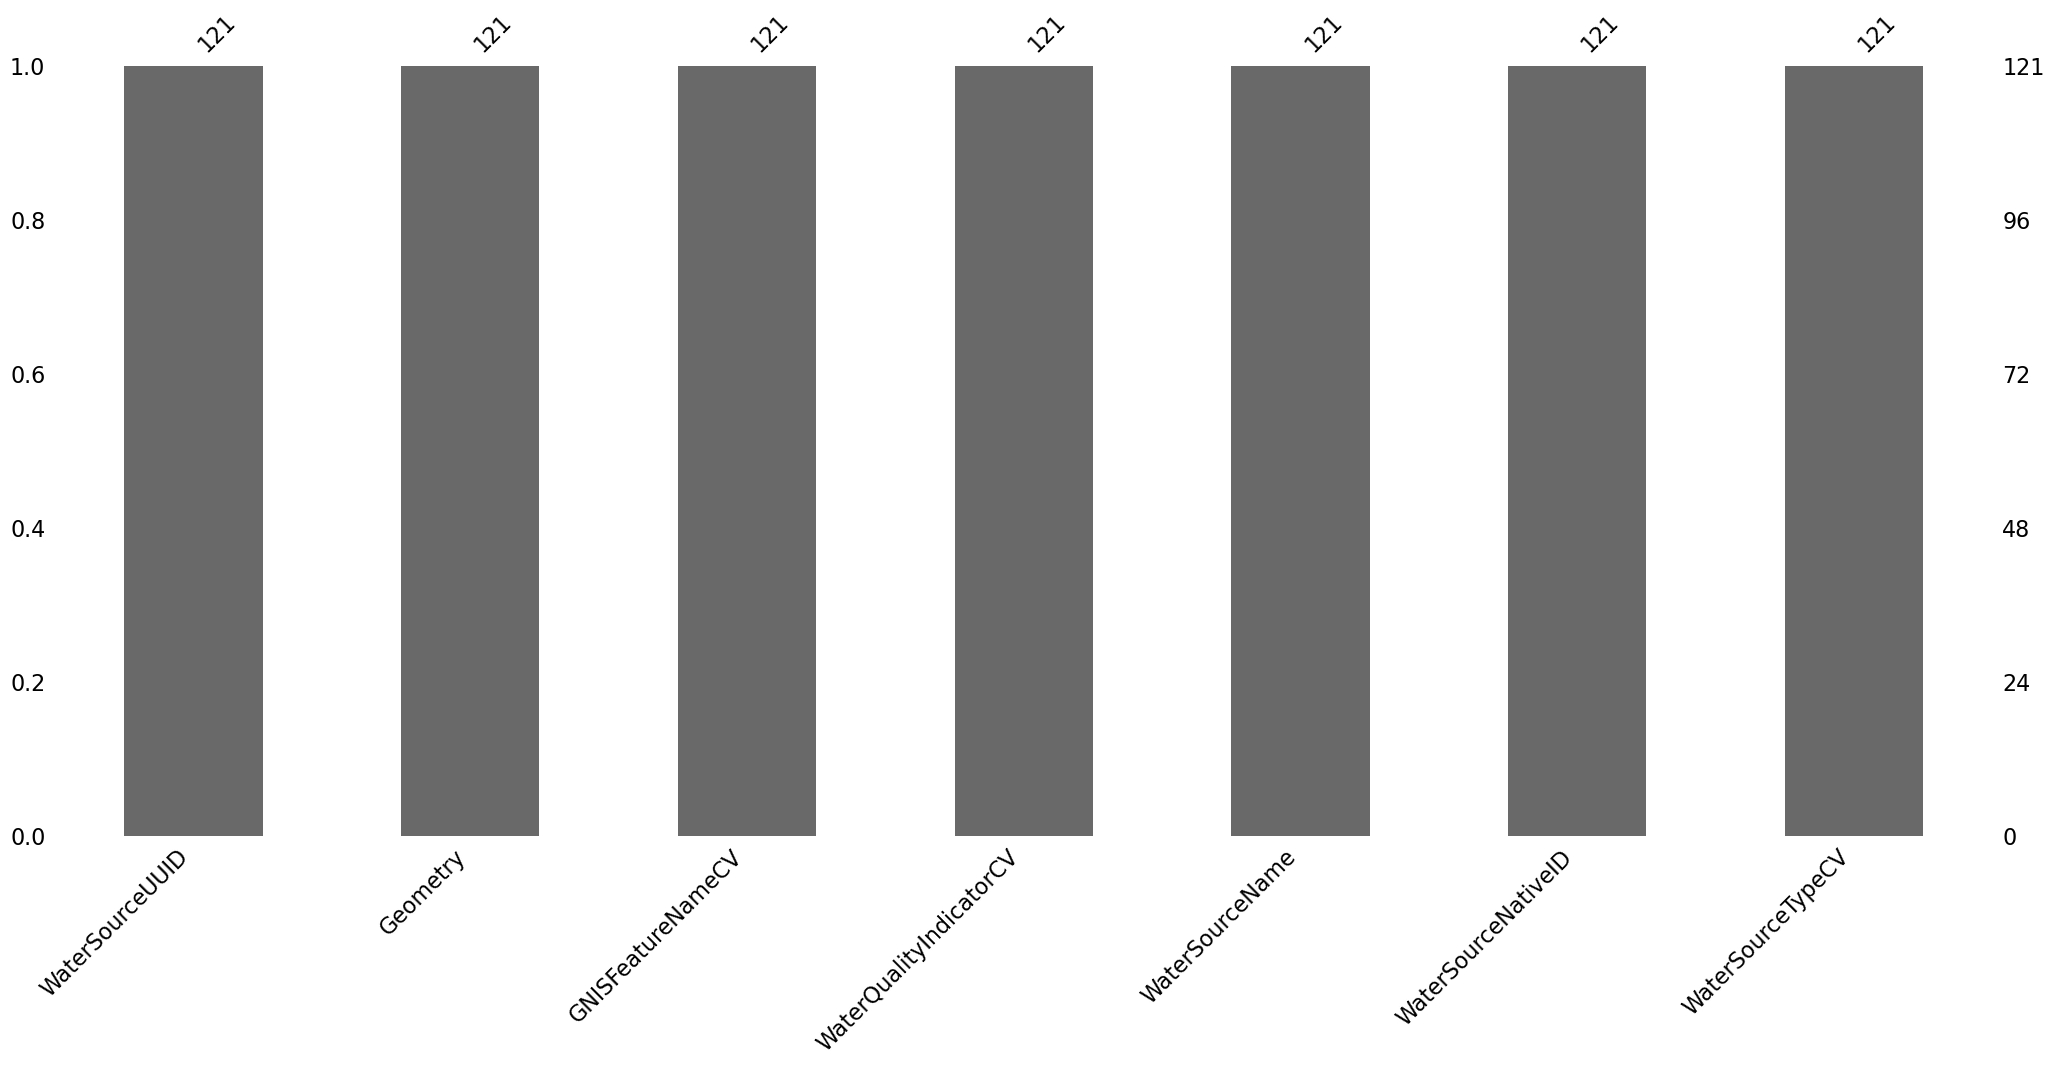

In [7]:
# Check what columns contain missing information.
msno.bar(dfws)

In [8]:
# Unique values for 'WaterSourceTypeCV'
for x in dfws['WaterSourceTypeCV'].sort_values().unique():
    print(f'"' + x + '",')

"Groundwater",
"Surface Water",


# Site Info (sites.csv)

In [9]:
print(len(dfs))
dfs.head(1)

34768


,SiteUUID,OverlayUUIDs,WaterSourceUUIDs,CoordinateAccuracy,CoordinateMethodCV,County,EPSGCodeCV,Geometry,GNISCodeCV,HUC12,HUC8,Latitude,Longitude,NHDNetworkStatusCV,NHDProductCV,PODorPOUSite,SiteName,SiteNativeID,SitePoint,SiteTypeCV,StateCV,USGSSiteID
0,KSwr_SPOD1,,KSwr_WwadeId23,WaDE Unspecified,WaDE Unspecified,Gray,4326,,,110400070105,11040007,37.52048,-100.44270,,,POD,Wade Unspecified,POD1,,WaDE Unspecified,KS,


<Axes: >

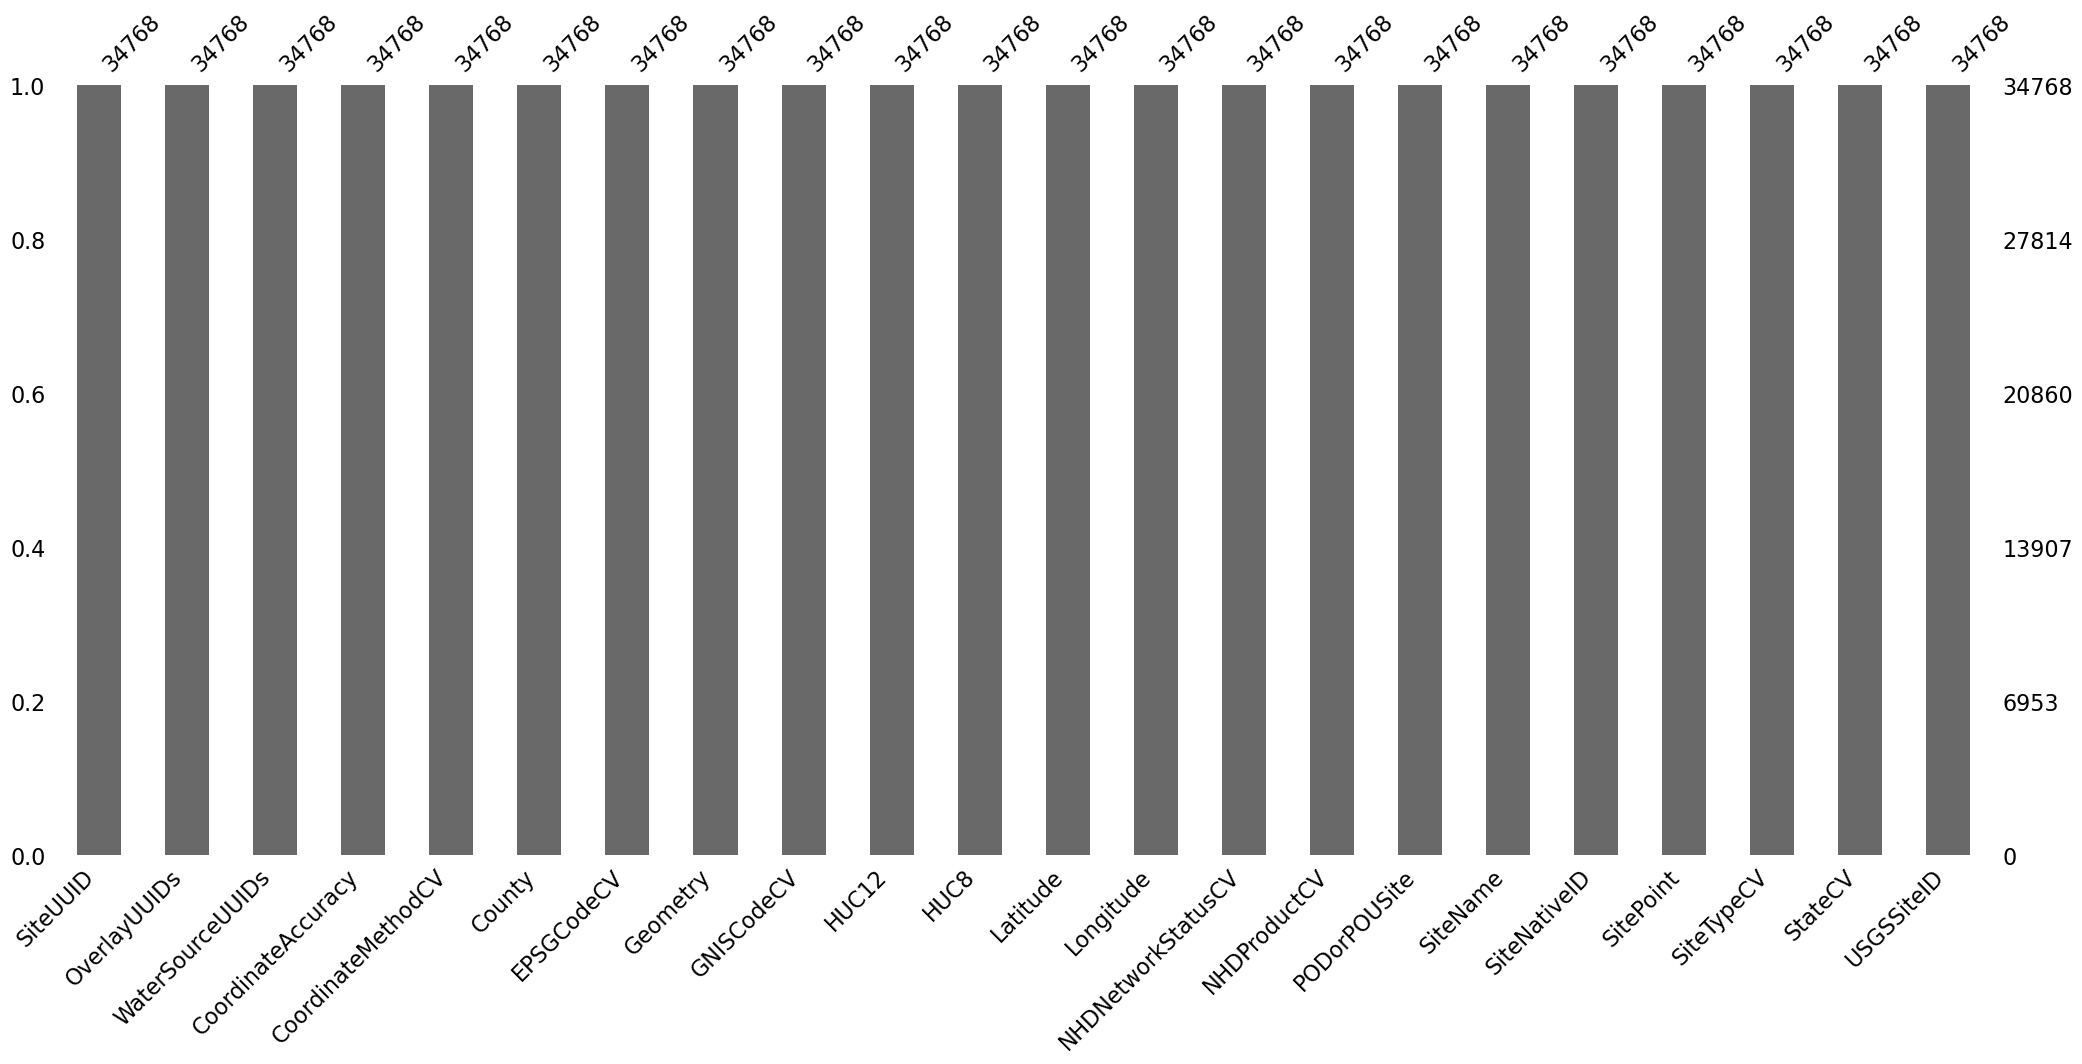

In [10]:
# Check what columns contain missing information.
msno.bar(dfs)

In [11]:
# Unique values for 'CoordinateMethodCV'
for x in dfs['CoordinateMethodCV'].sort_values().unique():
    print(f'"' + x + '",')

"WaDE Unspecified",


In [12]:
# Unique values for 'SiteTypeCV'
for x in dfs['SiteTypeCV'].sort_values().unique():
    print(f'"' + x + '",')

"WaDE Unspecified",


# Allocation Amount Info (waterallocations.csv)

In [13]:
print(len(dfaa))
dfaa.head(1)

31149


,AllocationUUID,MethodUUID,OrganizationUUID,SiteUUID,VariableSpecificUUID,AllocationApplicationDate,AllocationAssociatedConsumptiveUseSiteIDs,AllocationAssociatedWithdrawalSiteIDs,AllocationBasisCV,AllocationChangeApplicationIndicator,AllocationCommunityWaterSupplySystem,AllocationCropDutyAmount,AllocationExpirationDate,AllocationFlow_CFS,AllocationLegalStatusCV,AllocationNativeID,AllocationOwner,AllocationPriorityDate,AllocationSDWISIdentifierCV,AllocationTimeframeEnd,AllocationTimeframeStart,AllocationTypeCV,AllocationVolume_AF,BeneficialUseCategory,CommunityWaterSupplySystem,CropTypeCV,CustomerTypeCV,DataPublicationDate,DataPublicationDOI,ExemptOfVolumeFlowPriority,GeneratedPowerCapacityMW,IrrigatedAcreage,IrrigationMethodCV,LegacyAllocationIDs,OwnerClassificationCV,PopulationServed,PowerType,PrimaryBeneficialUseCategory,WaterAllocationNativeURL
0,KSwr_WRks10001,KSwr_M1,KSwr_O1,KSwr_SPOD50351,KSwr_V1,,,,WaDE Blank,,,,,0.00000,Certificated Issued,ks10001,Wade Unspecified,1964-02-19,,,,Appropriation,394.00000,Irrigation,,,,02/04/2026,,0,,0.00000,,,Unspecified,,,Agriculture Irrigation,http://geohydro.kgs.ku.edu/geohydro/wimas/wate...


<Axes: >

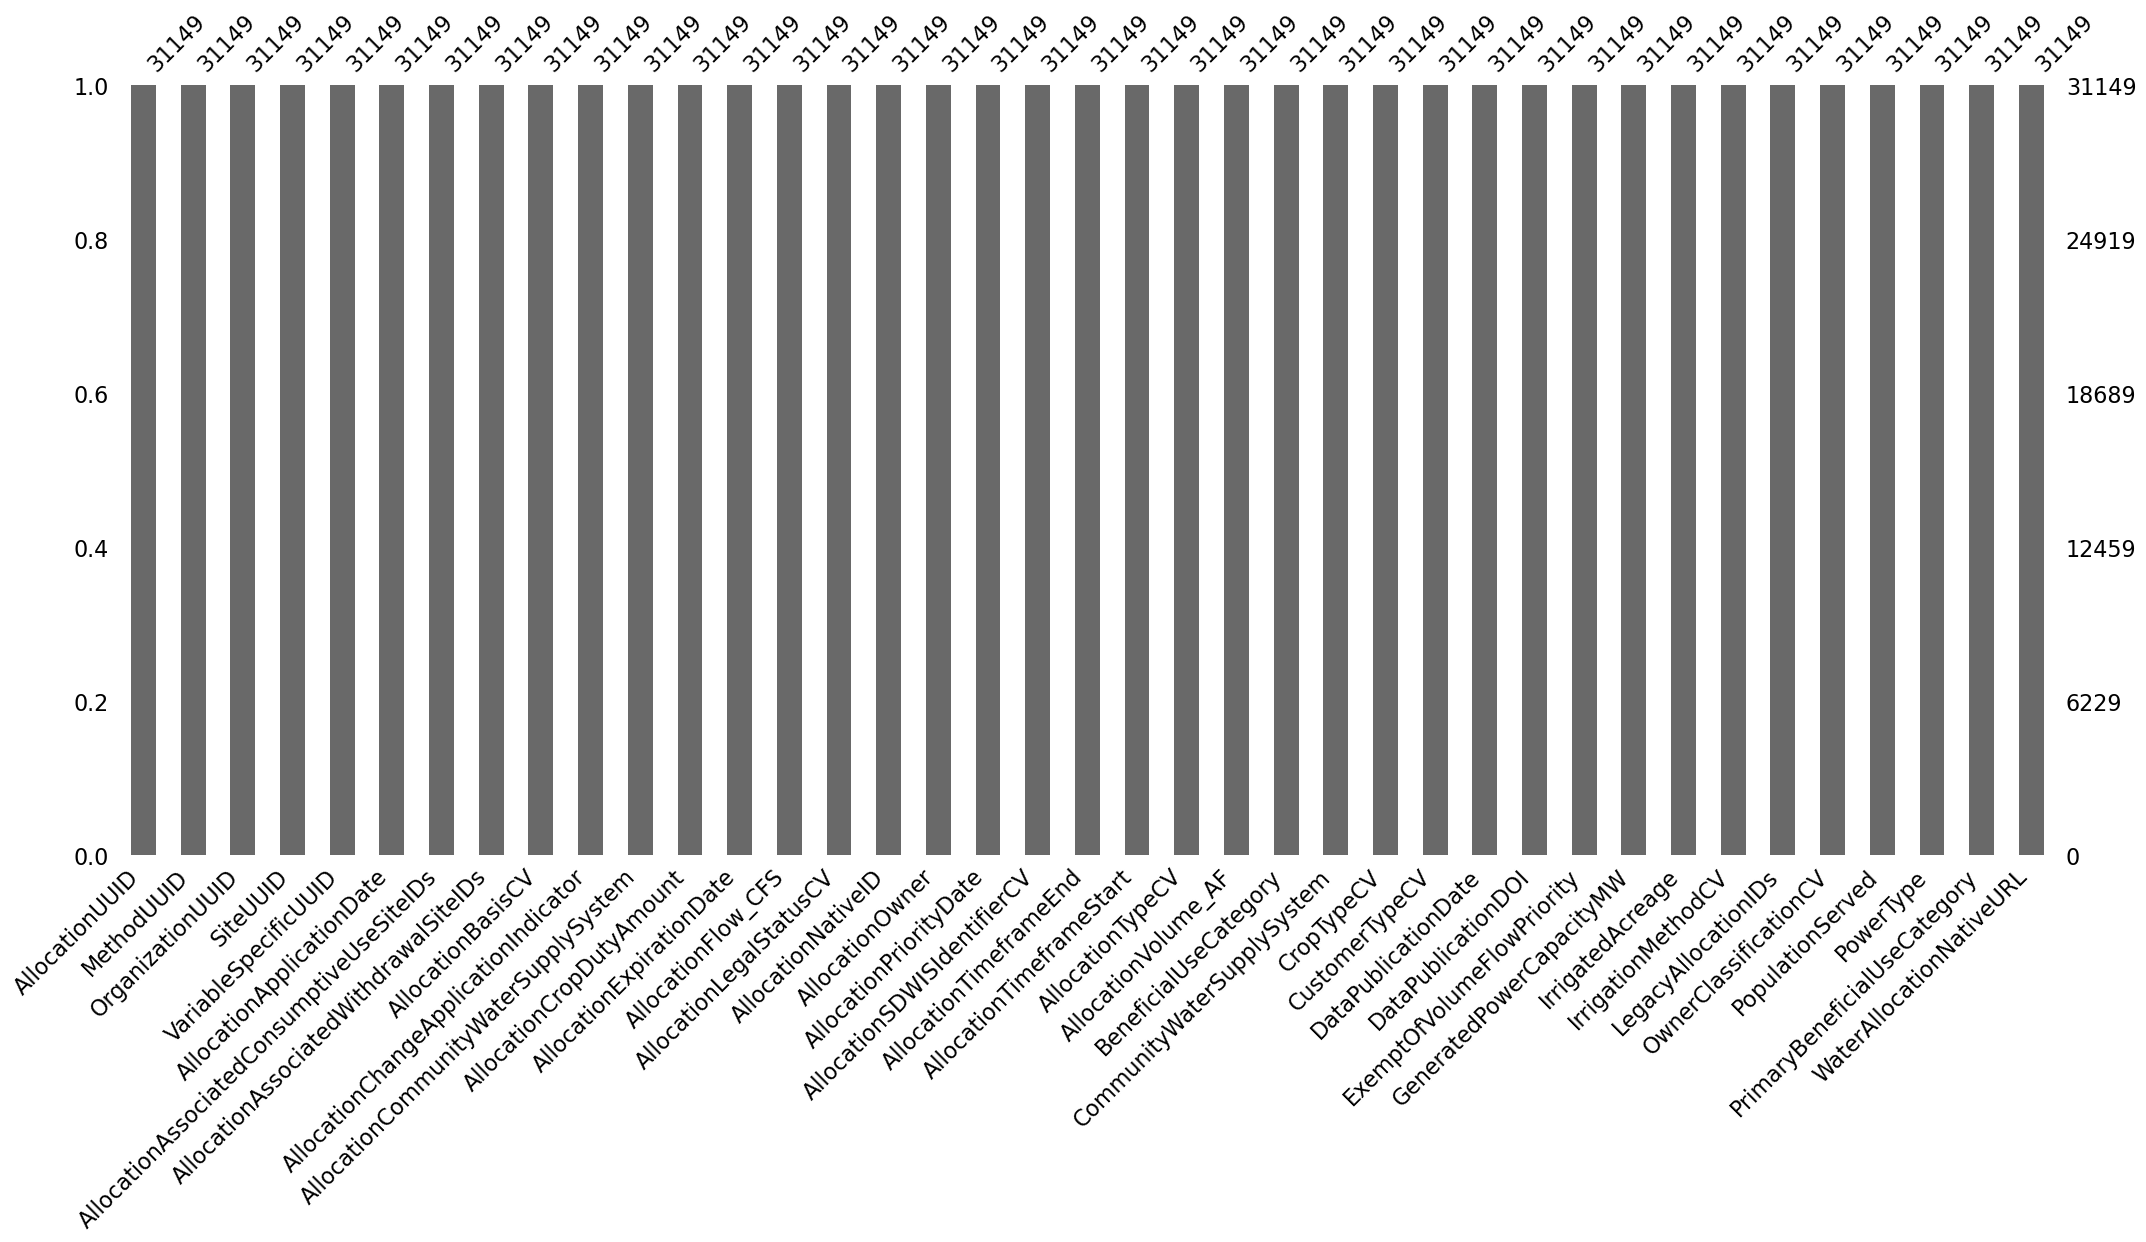

In [14]:
# Check what columns contain missing information.
msno.bar(dfaa)

In [15]:
# Unique values for 'AllocationBasisCV'
for x in dfaa['AllocationBasisCV'].sort_values().unique():
    print(f'"' + str(x) + '",')

"WaDE Blank",


In [16]:
# Unique values for 'AllocationTypeCV'
for x in dfaa['AllocationTypeCV'].sort_values().unique():
    print(f'"' + x + '",')

"Appropriation",
"Vested",


In [17]:
# Unique values for 'AllocationLegalStatusCV'
for x in dfaa['AllocationLegalStatusCV'].sort_values().unique():
    print(f'"' + x + '",')

"Approved Pending Completion",
"Certificated Issued",
"Completed Extended Time to Perfect",
"Completed Partial inspection",
"Completed Pending Inspection",
"Extended Time to Complete",
"Inspected Pending Perfection",
"Inspected Pending Perfection Extended Time to Perfect",
"Partial Inspection Extended Time to Perfect",
"Proposed Certificate",
"Proposed Certificate Extended Time to Perfect",
"Reinstated After Certificate Issued",
"Reinstated After Vested",
"Vested Active",


In [18]:
# Unique values for 'BeneficialUseCategory'
uniqueList = list(set([i.strip() for i in ','.join(dfaa['BeneficialUseCategory'].astype(str)).split(',')]))
uniqueList.sort()
uniqueList

['Domestic',
 'Industrial',
 'Irrigation',
 'Municipal',
 'Recreation',
 'Stockwater']

In [19]:
# Unique values for 'OwnerClassificationCV'
for x in dfaa['OwnerClassificationCV'].sort_values().unique():
    print(f'"' + x + '",')

"Unspecified",


## Markdown Table Creation

In [20]:
# method.csv
try:
  dftmp = dfm.loc[[0]].drop(['MethodDescription'], axis=1).copy().to_markdown()
except:
  dftmp = dfm.drop(['MethodDescription'], axis=1).copy().to_markdown()
print(dftmp)

|    | MethodUUID   | ApplicableResourceTypeCV   | DataConfidenceValue   | DataCoverageValue   | DataQualityValueCV   | MethodName                | MethodNEMILink                                                                         | MethodTypeCV    | WaDEDataMappingUrl                                                                     |
|---:|:-------------|:---------------------------|:----------------------|:--------------------|:---------------------|:--------------------------|:---------------------------------------------------------------------------------------|:----------------|:---------------------------------------------------------------------------------------|
|  0 | KSwr_M1      | Surface Ground Water       |                       |                     |                      | Kansas Water Right Method | https://agriculture.ks.gov/divisions-programs/dwr/water-appropriation/water-law-basics | Legal Processes | https://github.com/WSWCWaterDataExchange/MappingStatesDat

In [21]:
# variable.csv
try:
  dftmp = dfv.loc[[0]].copy().to_markdown()
except:
  dftmp = dfv.copy().to_markdown()
print(dftmp)

|    | VariableSpecificUUID   |   AggregationInterval | AggregationIntervalUnitCV   | AggregationStatisticCV   | AmountUnitCV   | MaximumAmountUnitCV   |   ReportYearStartMonth | ReportYearTypeCV   | VariableCV      | VariableSpecificCV   |
|---:|:-----------------------|----------------------:|:----------------------------|:-------------------------|:---------------|:----------------------|-----------------------:|:-------------------|:----------------|:---------------------|
|  0 | KSwr_V1                |                     1 | Year                        | Average                  | AF             | AF                    |                      1 | WaterYear          | Consumptive Use | Consumptive Use      |


In [22]:
# organizations.csv
try:
  dftmp = dfo.loc[[0]].copy().to_markdown()
except:
  dftmp = dfo.copy().to_markdown()
print(dftmp)

|    | OrganizationUUID   | OrganizationContactEmail   | OrganizationContactName   | OrganizationName                                                  | OrganizationPhoneNumber   | OrganizationPurview                                                                                                                        | OrganizationWebsite             | State   |
|---:|:-------------------|:---------------------------|:--------------------------|:------------------------------------------------------------------|:--------------------------|:-------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------------|:--------|
|  0 | KSwr_O1            | Ginger.Pugh@ks.gov         | Ginger Pugh               | The Kansas Department of Agriculture, Division of Water Resources | 785-564-6677              | The Division of Water Resources within the Kansas Department of Agriculture governs the

In [23]:
# watersources.csv
try:
  dftmp = dfws.loc[[0]].copy().to_markdown()
except:
  dftmp = dfws.copy().to_markdown()
print(dftmp)

|    | WaterSourceUUID   | Geometry   | GNISFeatureNameCV   | WaterQualityIndicatorCV   | WaterSourceName   | WaterSourceNativeID   | WaterSourceTypeCV   |
|---:|:------------------|:-----------|:--------------------|:--------------------------|:------------------|:----------------------|:--------------------|
|  0 | KSwr_WwadeId1     |            |                     | Fresh                     | Sappa Creek       | wadeId1               | Groundwater         |


In [24]:
# sites.csv
try:
  dftmp = dfs.loc[[0]].drop(['Geometry'], axis=1).copy().to_markdown()
except:
  dftmp = dfs.drop(['Geometry'], axis=1).copy().to_markdown()
print(dftmp)

|    | SiteUUID   | OverlayUUIDs   | WaterSourceUUIDs   | CoordinateAccuracy   | CoordinateMethodCV   | County   |   EPSGCodeCV | GNISCodeCV   |        HUC12 |     HUC8 |   Latitude |   Longitude | NHDNetworkStatusCV   | NHDProductCV   | PODorPOUSite   | SiteName         | SiteNativeID   | SitePoint   | SiteTypeCV       | StateCV   | USGSSiteID   |
|---:|:-----------|:---------------|:-------------------|:---------------------|:---------------------|:---------|-------------:|:-------------|-------------:|---------:|-----------:|------------:|:---------------------|:---------------|:---------------|:-----------------|:---------------|:------------|:-----------------|:----------|:-------------|
|  0 | KSwr_SPOD1 |                | KSwr_WwadeId23     | WaDE Unspecified     | WaDE Unspecified     | Gray     |         4326 |              | 110400070105 | 11040007 |    37.5205 |    -100.443 |                      |                | POD            | Wade Unspecified | POD1           |        

In [25]:
# waterallocations.csv
try:
  dftmp = dfaa.loc[[0]].copy().to_markdown()
except:
  dftmp = dfaa.copy().to_markdown()
print(dftmp)

|    | AllocationUUID   | MethodUUID   | OrganizationUUID   | SiteUUID       | VariableSpecificUUID   | AllocationApplicationDate   | AllocationAssociatedConsumptiveUseSiteIDs   | AllocationAssociatedWithdrawalSiteIDs   | AllocationBasisCV   | AllocationChangeApplicationIndicator   | AllocationCommunityWaterSupplySystem   | AllocationCropDutyAmount   | AllocationExpirationDate   |   AllocationFlow_CFS | AllocationLegalStatusCV   | AllocationNativeID   | AllocationOwner   | AllocationPriorityDate   | AllocationSDWISIdentifierCV   | AllocationTimeframeEnd   | AllocationTimeframeStart   | AllocationTypeCV   |   AllocationVolume_AF | BeneficialUseCategory   | CommunityWaterSupplySystem   | CropTypeCV   | CustomerTypeCV   | DataPublicationDate   | DataPublicationDOI   |   ExemptOfVolumeFlowPriority | GeneratedPowerCapacityMW   |   IrrigatedAcreage | IrrigationMethodCV   | LegacyAllocationIDs   | OwnerClassificationCV   | PopulationServed   | PowerType   | PrimaryBeneficialUseCategory   | Wa

## Num of Record Summary

In [26]:
# Num of entries of source data
print(f"Num of Source #1 Entries (rows): ", "|", len(dfin1))
print(f"Num of Source #2 Entries (rows): ", "|", len(dfin2))

Num of Source #1 Entries (rows):  | 47153
Num of Source #2 Entries (rows):  | 89150


In [27]:
# Num of entries compiled into WaDE
podString =  len(dfs[dfs['PODorPOUSite'] == 'POD'])
pouString=  len(dfs[dfs['PODorPOUSite'] == 'POU'])
aaString = len(dfaa)
print("Dataset  | Num of Identified PODs | Num of Identified POUs | Num of Identified Water Right Records")
print("**Compiled WaDE Data** |", podString, "|", pouString, "|", aaString)

Dataset  | Num of Identified PODs | Num of Identified POUs | Num of Identified Water Right Records
**Compiled WaDE Data** | 34768 | 0 | 31149


## Why Removed Records Summary

In [28]:
print("---- Reasons why records were removed from water source info ----")
if len(dfwspurge) != 0:
    print(dfwspurge['ReasonRemoved'].value_counts().astype(str) + " | removed from watersources.csv input")
else:
    print("...nothing removed.")

---- Reasons why records were removed from water source info ----
...nothing removed.


In [29]:
print(" ---- Reasons why records were removed from site info ---- ")
if len(dfspurge) != 0:
    print(dfspurge['ReasonRemoved'].value_counts().astype(str) + " | removed from sites.csv input")
else:
    print("...nothing removed.")

 ---- Reasons why records were removed from site info ---- 
ReasonRemoved
Unused Site Record    5167 | removed from sites.csv input
Name: count, dtype: object


In [30]:
print(" ---- Reasons why records were removed from allocation amount info ---- ")
if len(dfaapurge) != 0:
    print(dfaapurge['ReasonRemoved'].value_counts().astype(str) + " | removed from waterallocations.csv input")
else:
    print("...nothing removed.")

 ---- Reasons why records were removed from allocation amount info ---- 
ReasonRemoved
Incomplete or bad entry for Volume                     2269 | removed from waterallocations.csv input
Incomplete or bad entry for AllocationLegalStatusCV     683 | removed from waterallocations.csv input
Name: count, dtype: object


## Figures

In [31]:
# ---- merge watersource.csv to sites.csv ----

# explode site.csv on WaterSourceUUIDs
dfstemp = dfs.copy()
dfstemp = dfstemp.assign(WaterSourceUUIDs=dfstemp['WaterSourceUUIDs'].str.split(',')).explode('WaterSourceUUIDs').reset_index(drop=True)

# merge
dfstemp_ws = pd.merge(dfstemp, dfws[['WaterSourceUUID', 'WaterSourceTypeCV']], left_on='WaterSourceUUIDs', right_on='WaterSourceUUID', how='left')

# groupby site-watersource.csv via SiteUUID
dfstemp_ws = dfstemp_ws.groupby('SiteUUID').agg(lambda x: ','.join([str(elem) for elem in (list(set(x))) if elem != ""])).replace(np.nan, "").reset_index()

print(len(dfstemp_ws))
dfstemp_ws.head(1)

34768


,SiteUUID,OverlayUUIDs,WaterSourceUUIDs,CoordinateAccuracy,CoordinateMethodCV,County,EPSGCodeCV,Geometry,GNISCodeCV,HUC12,HUC8,Latitude,Longitude,NHDNetworkStatusCV,NHDProductCV,PODorPOUSite,SiteName,SiteNativeID,SitePoint,SiteTypeCV,StateCV,USGSSiteID,WaterSourceUUID,WaterSourceTypeCV
0,KSwr_SPOD1,,KSwr_WwadeId23,WaDE Unspecified,WaDE Unspecified,Gray,4326,,,110400070105,11040007,37.52048110961914,-100.44270324707033,,,POD,Wade Unspecified,POD1,,WaDE Unspecified,KS,,KSwr_WwadeId23,Groundwater


PODorPOUSite
POD    34768
Name: count, dtype: int64


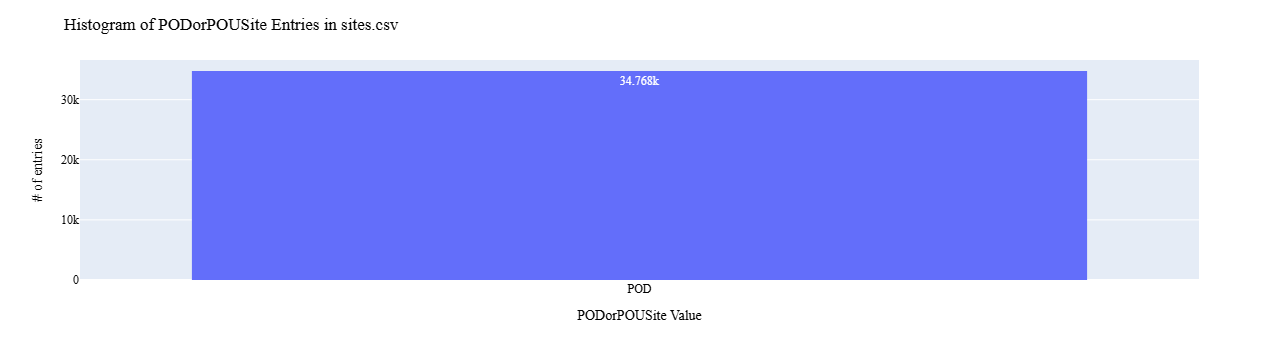

C:\Users\rjame\AppData\Local\Temp\ipykernel_4916\1965001943.py:16: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [32]:
# ---- Histogram: Num of POD sites vs POU sites ----
print(dfstemp_ws.PODorPOUSite.value_counts())

fig = px.histogram(dfstemp_ws, x="PODorPOUSite", text_auto=True)
fig.update_layout(bargap=0.2,
                  title="Histogram of PODorPOUSite Entries in sites.csv",
                  xaxis_title="PODorPOUSite Value",
                  yaxis_title="# of entries",
                  #legend_title="Legend Title",
                    font=dict(
                        family="Arial Bold",
                        size=12,
                        color="Black")
                 )
fig.show()
fig.write_image('figures/PODorPOUSite.png', engine="kaleido")

In [33]:
# ---- Histogram: Num of sites via WatersourceTypeCV ----
print(dfstemp_ws.WaterSourceTypeCV.value_counts())

fig = px.histogram(dfstemp_ws, x="WaterSourceTypeCV", text_auto=True)
fig.update_layout(bargap=0.2,
                  title="Histogram of WaterSourceTypeCV Entries in sites.csv",
                  xaxis_title="WaterSourceTypeCV Value",
                  yaxis_title="# of entries",
                  #legend_title="Legend Title",
                    font=dict(
                        family="Arial Bold",
                        size=12,
                        color="Black")
                 )
fig.show()
fig.write_image('figures/WaterSourceTypeCV.png', engine="kaleido")

WaterSourceTypeCV
Groundwater                  30851
Surface Water                 3907
Groundwater,Surface Water       10
Name: count, dtype: int64


C:\Users\rjame\AppData\Local\Temp\ipykernel_4916\1738051229.py:16: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [34]:
# ---- Histogram: Distribution of PrimaryBeneficialUseCategory WaDE Values ----
print(dfaa.PrimaryBeneficialUseCategory.value_counts())

fig = px.histogram(dfaa, x="PrimaryBeneficialUseCategory", text_auto=True)
fig.update_layout(bargap=0.2,
                  title="Histogram of WaDE PrimaryBeneficialUseCategory Entries in waterallocations.csv",
                  xaxis_title="PrimaryBeneficialUseCategory Value",
                  yaxis_title="# of entries",
                  #legend_title="Legend Title",
                    font=dict(
                        family="Arial Bold",
                        size=12,
                        color="Black")
                 )
fig.show()
fig.write_image('figures/PrimaryBeneficialUseCategory.png', engine="kaleido")

PrimaryBeneficialUseCategory
Agriculture Irrigation    25803
Public Supply              1965
Recreation                 1246
Livestock                   867
Commercial/Industrial       796
Domestic                    472
Name: count, dtype: int64


C:\Users\rjame\AppData\Local\Temp\ipykernel_4916\3144699730.py:16: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [35]:
# ---- AllocationPriorityDate #1: histogram distribution of WaDE values 
print(dfaa.AllocationPriorityDate.value_counts())

dfaatemp = dfaa.copy()
dfaatemp = dfaatemp[(dfaatemp['ExemptOfVolumeFlowPriority'] < 1)].reset_index(drop=True)
fig = px.histogram(dfaatemp, x="AllocationPriorityDate")
fig.update_layout(bargap=0.2,
                  title="Histogram of AllocationPriorityDate Entries in waterallocations.csv",
                  xaxis_title="AllocationPriorityDate Value",
                  yaxis_title="# of entries",
                  #legend_title="Legend Title",
                    font=dict(
                        family="Arial Bold",
                        size=12,
                        color="Black")
                 )
fig.show()
fig.write_image('figures/AllocationPriorityDate1.png', engine="kaleido")

AllocationPriorityDate
1945-06-28    1378
1977-01-03      38
1976-09-07      38
1978-01-03      36
1976-12-20      36
              ... 
1952-11-29       1
1995-11-03       1
1995-11-06       1
1995-11-15       1
1995-11-20       1
Name: count, Length: 11314, dtype: int64


C:\Users\rjame\AppData\Local\Temp\ipykernel_4916\3323753691.py:18: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [36]:
# ---- AllocationPriorityDate #2: cumulative distribution of WaDE values 
print(dfaa.AllocationPriorityDate.value_counts())

dfaatemp = dfaa.copy()
dfaatemp = dfaatemp[(dfaatemp['ExemptOfVolumeFlowPriority'] < 1)].reset_index(drop=True)
fig = px.ecdf(dfaatemp, x="AllocationPriorityDate", ecdfnorm=None)
fig.update_layout(bargap=0.2,
                  title="Cumulative Distribution of AllocationPriorityDate Entries in waterallocations.csv",
                  xaxis_title="AllocationPriorityDate Value",
                  yaxis_title="# of entries",
                  #legend_title="Legend Title",
                    font=dict(
                        family="Arial Bold",
                        size=12,
                        color="Black")
                 )
fig.show()
fig.write_image('figures/AllocationPriorityDate2.png', engine="kaleido")

AllocationPriorityDate
1945-06-28    1378
1977-01-03      38
1976-09-07      38
1978-01-03      36
1976-12-20      36
              ... 
1952-11-29       1
1995-11-03       1
1995-11-06       1
1995-11-15       1
1995-11-20       1
Name: count, Length: 11314, dtype: int64


C:\Users\rjame\AppData\Local\Temp\ipykernel_4916\1508418406.py:18: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




AllocationLegalStatusCV
Certificated Issued                                      27188
Vested Active                                             1383
Inspected Pending Perfection Extended Time to Perfect      658
Completed Pending Inspection                               607
Completed Extended Time to Perfect                         359
Inspected Pending Perfection                               342
Approved Pending Completion                                292
Proposed Certificate                                       209
Extended Time to Complete                                   82
Reinstated After Certificate Issued                         14
Proposed Certificate Extended Time to Perfect                7
Partial Inspection Extended Time to Perfect                  3
Completed Partial inspection                                 3
Reinstated After Vested                                      2
Name: count, dtype: int64


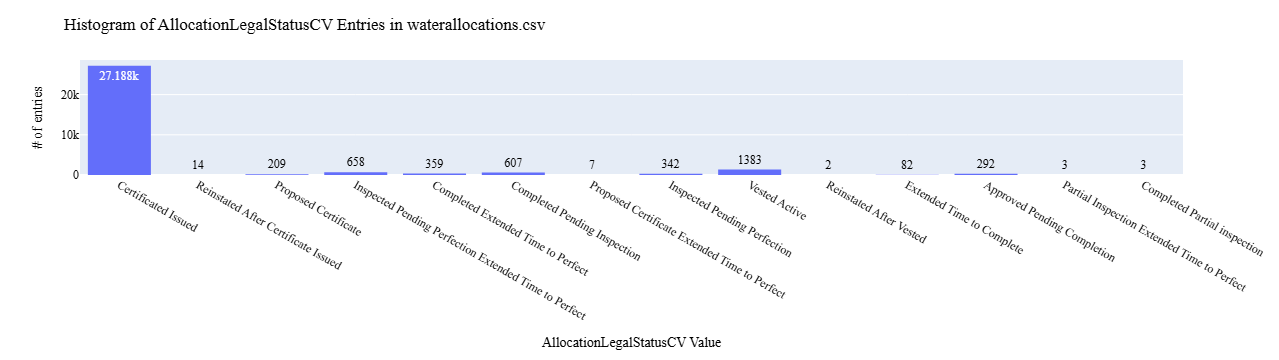

C:\Users\rjame\AppData\Local\Temp\ipykernel_4916\4104672489.py:16: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [37]:
# ---- AllocationLegalStatusCV: histogram distribution of WaDE values ----
print(dfaa.AllocationLegalStatusCV.value_counts())

fig = px.histogram(dfaa, x="AllocationLegalStatusCV", text_auto=True)
fig.update_layout(bargap=0.2,
                  title="Histogram of AllocationLegalStatusCV Entries in waterallocations.csv",
                  xaxis_title="AllocationLegalStatusCV Value",
                  yaxis_title="# of entries",
                  #legend_title="Legend Title",
                    font=dict(
                        family="Arial Bold",
                        size=12,
                        color="Black")
                 )
fig.show()
fig.write_image('figures/AllocationLegalStatusCV.png', engine="kaleido")

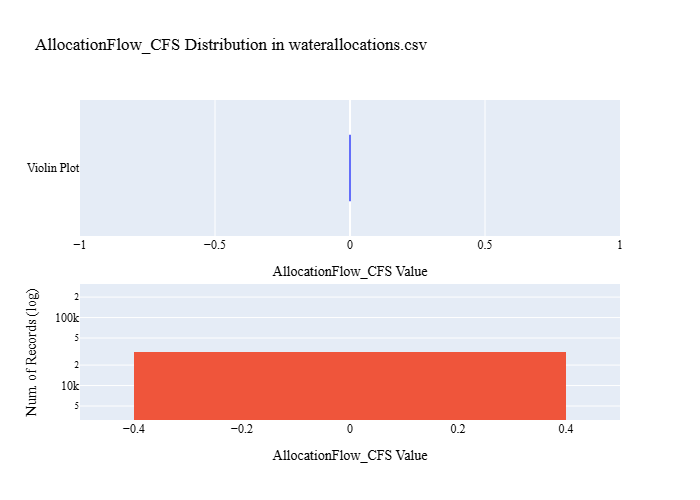

C:\Users\rjame\AppData\Local\Temp\ipykernel_4916\2804319279.py:16: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [38]:
# ---- AllocationFlow_CFS: Boxplot distribution of WaDE values ----

try: 
    trace1 = go.Violin(x=dfaa['AllocationFlow_CFS'], points='outliers', name='Violin Plot')
    trace2 = go.Histogram(x=dfaa['AllocationFlow_CFS'], name='Historgram')

    fig = make_subplots(rows=2, cols=1)
    fig.add_trace(trace1, row=1, col=1)
    fig.add_trace(trace2, row=2, col=1)

    fig.update_layout(showlegend=False, bargap=0.2, title="AllocationFlow_CFS Distribution in waterallocations.csv", font=dict(family="Arial Bold", size=12,color="Black"))
    fig.update_xaxes(title_text="AllocationFlow_CFS Value", row=1, col=1)
    fig.update_xaxes(title_text="AllocationFlow_CFS Value", row=2, col=1)
    fig.update_yaxes(title_text="Num. of Records (log)", row=2, col=1, type="log")
    fig.show(renderer="png")
    fig.write_image('figures/AllocationFlow_CFS.png', engine="kaleido")

except: print('Could not plot AllocationFlow_CFS value.')

In [39]:
# ---- Amount: Boxplot distribution of WaDE values ----

try: 
    trace1 = go.Violin(x=dfsa['Amount'], points='outliers', name='Violin Plot')
    trace2 = go.Histogram(x=dfsa['Amount'], name='Historgram')

    fig = make_subplots(rows=2, cols=1)
    fig.add_trace(trace1, row=1, col=1)
    fig.add_trace(trace2, row=2, col=1)

    fig.update_layout(showlegend=False, bargap=0.2, title="Amount Distribution in sitespecificamounts.csv", font=dict(family="Arial Bold", size=12,color="Black"))
    fig.update_xaxes(title_text="Amount Value", row=1, col=1)
    fig.update_xaxes(title_text="Amount Value", row=2, col=1)
    fig.update_yaxes(title_text="Num. of Records (log)", row=2, col=1, type="log")
    fig.show(renderer="png")
    fig.write_image('figures/Amount.png', engine="kaleido")

except: print('Could not plot Amount value.')

Could not plot Amount value.


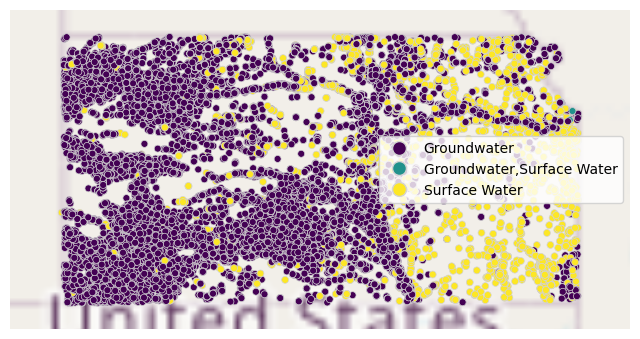

In [40]:
# ---- Map of Points sites ----

dfstemp = dfstemp_ws.copy()
dfstemp = dfstemp[dfstemp['Geometry'] == ''].reset_index(drop=True)

try:
    contiguous_usa = gpd.read_file(gplt.datasets.get_path('contiguous_usa')) # use for background map in subplot
    ax = gplt.webmap(contiguous_usa, projection=gcrs.WebMercator()) # set subplot
    gdfstemp = gpd.GeoDataFrame(dfstemp, geometry=gpd.points_from_xy(dfstemp.Longitude.astype(float), dfstemp.Latitude.astype(float)), crs="EPSG:4326")
    gplt.pointplot(gdfstemp, hue='WaterSourceTypeCV', edgecolor='lightgray', linewidth=0.5, legend=True, legend_var='hue', ax=ax)
    mplt.savefig(format="png", fname='figures/PointMap.png') 
except:
    print('No point data to plot')

No geometry data to plot


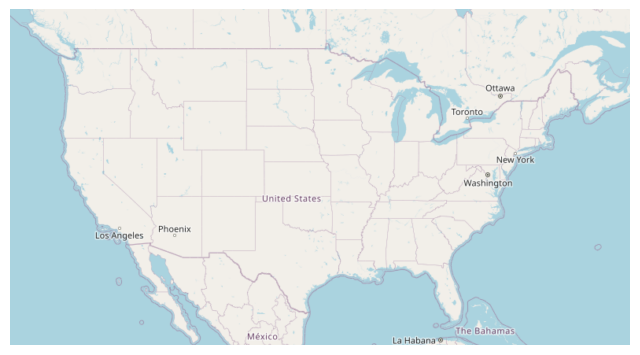

In [41]:
# ---- Map of Polygons ----

dfstemp = dfstemp_ws.copy()
dfstemp = dfstemp[dfstemp['Geometry'] != ""].reset_index(drop=True)

try:
    contiguous_usa = gpd.read_file(gplt.datasets.get_path('contiguous_usa')) # use for background map in subplot
    ax = gplt.webmap(contiguous_usa, projection=gcrs.WebMercator()) # set subplot

    dfstemp['Geometry'] = gpd.GeoSeries.from_wkt(dfstemp['Geometry'], crs="EPSG:4326")
    gdfstemp = gpd.GeoDataFrame(dfstemp, geometry=dfstemp['Geometry'], crs="EPSG:4326") # covert to geodataframe
    gplt.choropleth(gdfstemp, edgecolor='lightgray', linewidth=0.5, hue='WaterSourceTypeCV', legend=True, ax=ax)
    mplt.savefig(format="png", fname='figures/PolyMap.png')
except:
    print('No geometry data to plot')

# Removed Records compared to Source Data
- this is working just fine, just want to comment out temporarily for future use

In [42]:
# # Explode purge.xlsx files by WaDEUUID, concat together
# #################################################################

# # Explode watersources_missing.xlsx records by WaDEUUID
# dfwspurgeCopy = dfwspurge.assign(WaDEUUID=dfwspurge['WaDEUUID'].str.split(',')).explode('WaDEUUID').reset_index(drop=True)
# dfwspurgeCopy = dfwspurgeCopy[['WaDEUUID','ReasonRemoved','IncompleteField']]

# # Explode sites_missing.xlsx records by WaDEUUID
# dfspurgeCopy = dfspurge.assign(WaDEUUID=dfspurge['WaDEUUID'].str.split(',')).explode('WaDEUUID').reset_index(drop=True)
# dfspurgeCopy = dfspurgeCopy[['WaDEUUID','ReasonRemoved','IncompleteField']]

# # Explode waterallocations_missing.xlsx records by WaDEUUID
# dfaapurgeCopy = dfaapurge.assign(WaDEUUID=dfaapurge['WaDEUUID'].str.split(',')).explode('WaDEUUID').reset_index(drop=True)
# dfaapurgeCopy = dfaapurgeCopy[['WaDEUUID','ReasonRemoved','IncompleteField']]

# # concat purge dataframes togehter
# frames = [dfwspurgeCopy, dfspurgeCopy, dfaapurgeCopy] 
# dfWaDEUUID = pd.concat(frames)
# dfWaDEUUID = dfWaDEUUID.drop_duplicates().reset_index(drop=True).replace(np.nan, "")
# print(len(dfWaDEUUID))
# dfWaDEUUID.head(1)

# Custom Queries and Analysis for this Dataset

In [43]:
# N/A